<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_11_4_gradients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 11: Troubleshooting and Evaluating PyTorch Models**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 11 Material

* Part 11.1: Debugging with PyTorch Networks [[Notebook]](t81_558_class_11_1_debugging_pytorch.ipynb)
* Part 11.2: Critical PyTorch Errors [[Notebook]](t81_558_class_11_2_critical_errors.ipynb)
* Part 11.3: Overfitting and Underfitting [[Notebook]](t81_558_class_11_3_overfitting.ipynb)
* **Part 11.4: Vanishing and Exploding Gradients** [[Notebook]](t81_558_class_11_4_gradients.ipynb)
* Part 11.5: Error Metrics Beyond Accuracy [[Notebook]](t81_558_class_11_5_metrics.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 11.4: Vanishing and Exploding Gradients

Deep networks learn by propagating gradients backward from the loss through every layer. This backward flow is a long chain of multiplications, one factor for each layer the gradient passes through. When those factors are consistently smaller than one, their product shrinks toward zero as it travels back through the network, and the earliest layers receive almost no learning signal. This is the **vanishing gradient** problem. When the factors are consistently larger than one, their product grows without bound, and the gradients, and the weight updates they drive, become enormous. This is the **exploding gradient** problem.

Both failures are consequences of depth. A shallow network multiplies only a few factors together, so the product stays well behaved. A deep network multiplies many, and any consistent bias toward small or large factors compounds exponentially with depth. Vanishing gradients leave the early layers effectively frozen, so the network trains slowly or stalls entirely. Exploding gradients make training unstable, with the loss swinging wildly or turning into `NaN`.

This section makes both problems observable. We will build a deep network, measure the gradient norm at every layer, and see how the choice of activation function determines whether gradients vanish. We will then provoke exploding gradients and apply the standard countermeasure, gradient clipping. Along the way we connect these effects to the design choices, activations, initialization, and normalization, that keep gradients healthy in modern networks.

## Why Gradients Vanish or Explode

The backward pass computes the gradient of the loss with respect to each layer's parameters using the chain rule. For a layer deep in the network, that gradient is a product of terms contributed by every layer between it and the loss. Two of those terms matter most: the derivative of each activation function, and the magnitude of each weight matrix.

Saturating activation functions are the classic cause of vanishing gradients. The sigmoid function, for example, flattens out for inputs far from zero, and its derivative there is nearly zero, at most 0.25 even at its steepest. Multiply a dozen such factors together on the way back through a deep network and the gradient reaching the early layers is vanishingly small. The `tanh` activation has the same problem to a lesser degree. The `ReLU` activation was adopted so widely precisely because its derivative is exactly one for positive inputs, so it does not shrink gradients as they pass through.

Exploding gradients come from the opposite imbalance. If the weight matrices have large magnitude, whether from poor initialization or from growth during training, each factor in the backward product is greater than one, and the product grows exponentially with depth. The result is gradients so large that a single optimizer step throws the weights far from any useful region, often producing `NaN` values from which training cannot recover.

## Detecting the Problem: Per-Layer Gradient Norms

The way to see these effects directly is to measure the norm of the gradient at each layer after a backward pass. A healthy network shows gradients of roughly comparable magnitude across its depth. A network with vanishing gradients shows norms that shrink by orders of magnitude toward the input side. A network with exploding gradients shows norms that grow to very large values.

The experiment below builds a deep, twelve-layer network twice: once with sigmoid activations and once with ReLU. For each, it runs a single backward pass and collects the gradient norm of every linear layer's weights, ordered from the input side to the output side. Comparing the two makes the effect of the activation choice on gradient flow unmistakable.

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)


def deep_net(activation, depth=12, width=64):
    layers = []
    for _ in range(depth):
        layers += [nn.Linear(width, width), activation()]
    layers += [nn.Linear(width, 1)]
    return nn.Sequential(*layers)


def layer_grad_norms(model):
    x = torch.randn(64, 64)
    target = torch.randn(64, 1)
    model.zero_grad()
    loss = nn.MSELoss()(model(x), target)
    loss.backward()
    # Gradient norm of each Linear layer's weights, input side first.
    return [m.weight.grad.norm().item() for m in model if isinstance(m, nn.Linear)]


sigmoid_norms = layer_grad_norms(deep_net(nn.Sigmoid))
relu_norms = layer_grad_norms(deep_net(nn.ReLU))

print("Weight-gradient norm by layer (layer 0 = input side):")
print(f"{'layer':>6} {'sigmoid':>12} {'relu':>12}")
for i, (s, r) in enumerate(zip(sigmoid_norms, relu_norms)):
    print(f"{i:>6} {s:>12.2e} {r:>12.2e}")

Weight-gradient norm by layer (layer 0 = input side):
 layer      sigmoid         relu
     0     1.55e-10     3.13e-05
     1     2.71e-10     3.06e-05
     2     1.54e-09     3.83e-05
     3     1.19e-08     5.54e-05
     4     8.21e-08     8.22e-05
     5     5.52e-07     1.54e-04
     6     4.01e-06     4.65e-04
     7     3.35e-05     1.25e-03
     8     2.09e-04     2.95e-03
     9     1.30e-03     6.29e-03
    10     1.11e-02     1.63e-02
    11     7.20e-02     3.83e-02
    12     4.96e-01     1.13e-01


The numbers tell the story of the backward pass. With sigmoid activations, the gradient norm shrinks dramatically from the output side to the input side, often by several orders of magnitude, so the earliest layers receive almost no signal and barely learn. With ReLU activations, the gradient norms stay far more uniform across depth, because ReLU does not attenuate the gradient the way a saturating sigmoid does. Plotting these norms on a logarithmic scale makes the contrast visual.

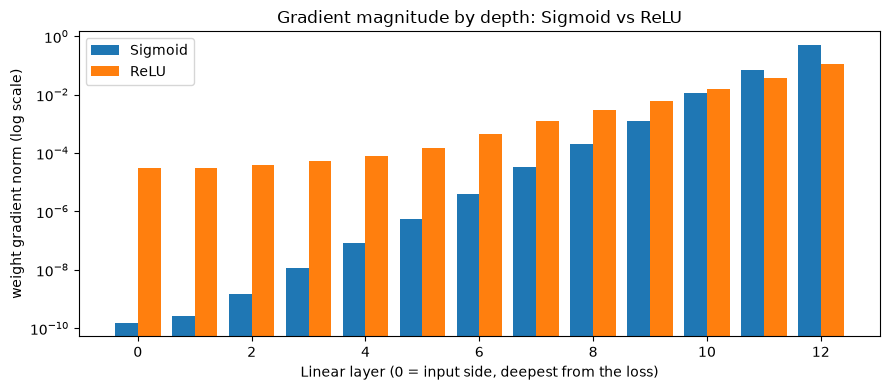

In [3]:
idx = np.arange(len(sigmoid_norms))

plt.figure(figsize=(9, 4))
plt.bar(idx - 0.2, sigmoid_norms, width=0.4, label="Sigmoid")
plt.bar(idx + 0.2, relu_norms, width=0.4, label="ReLU")
plt.yscale("log")
plt.xlabel("Linear layer (0 = input side, deepest from the loss)")
plt.ylabel("weight gradient norm (log scale)")
plt.title("Gradient magnitude by depth: Sigmoid vs ReLU")
plt.legend()
plt.tight_layout()
plt.show()

On the log-scaled axis, the sigmoid bars descend like a staircase toward the input side, each layer's gradient a fraction of the one after it, the exponential decay of the vanishing-gradient problem made visible. The ReLU bars stay much closer to a common level across the whole depth. This single picture explains why the field largely abandoned sigmoid and tanh activations for hidden layers in deep networks in favor of ReLU and its variants.

## Exploding Gradients and Gradient Clipping

The opposite problem, exploding gradients, is easy to provoke by inflating the network's weights so that every factor in the backward product is larger than one. We take the same deep ReLU network and scale up its initial weights, then measure the global gradient norm across all parameters. The result is a gradient far larger than any reasonable optimizer step should follow.

The standard remedy is **gradient clipping**. Before the optimizer step, `torch.nn.utils.clip_grad_norm_` computes the global norm of all gradients and, if it exceeds a chosen threshold, rescales every gradient down so the norm equals the threshold. This preserves the *direction* of the update while capping its *magnitude*, preventing a single explosive step from destroying the model. Gradient clipping is standard practice when training recurrent networks and transformers, where exploding gradients are common.

In [4]:
torch.manual_seed(0)
model = deep_net(nn.ReLU, depth=12, width=64)

# Deliberately inflate the initial weights to provoke instability.
with torch.no_grad():
    for m in model:
        if isinstance(m, nn.Linear):
            m.weight.mul_(2.5)

x = torch.randn(64, 64)
target = torch.randn(64, 1)
model.zero_grad()
loss = nn.MSELoss()(model(x), target)
loss.backward()

# Measure the global gradient norm before clipping.
before = torch.sqrt(sum(p.grad.pow(2).sum() for p in model.parameters()))

# Clip to a maximum global norm of 1.0. The function returns the PRE-clip norm.
reported = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

# Measure again after clipping.
after = torch.sqrt(sum(p.grad.pow(2).sum() for p in model.parameters()))

print(f"Global gradient norm before clipping: {before:.2f}")
print(f"Norm reported by clip_grad_norm_:     {reported:.2f}")
print(f"Global gradient norm after clipping:  {after:.2f}")

Global gradient norm before clipping: 133.37
Norm reported by clip_grad_norm_:     133.37
Global gradient norm after clipping:  1.00


The gradient norm before clipping is very large, the signature of an exploding gradient, and following an update of that size would wreck the model. After clipping, the global norm is capped at the threshold of 1.0, turning a destructive step into a controlled one. The value reported by `clip_grad_norm_` matches the pre-clip measurement, because the function returns the original norm so you can monitor how often and how severely clipping is triggering during training.

## Keeping Gradients Healthy

Detecting vanishing and exploding gradients is only useful if you know how to fix them, and modern deep learning offers a well-established toolkit. Each item addresses the root causes we saw above.

* **Activation choice.** Replacing saturating activations with `ReLU` or a variant such as `LeakyReLU` or `GELU` is the first defense against vanishing gradients, as the experiment above demonstrated. These activations are covered in [Module 7.3](t81_558_class_07_3_transfer.ipynb).
* **Careful initialization.** Schemes such as Xavier and Kaiming initialization set the initial weight scale so that the variance of activations and gradients is preserved across layers, keeping the backward product near one. PyTorch applies sensible defaults, but initialization matters most in very deep networks.
* **Normalization layers.** Batch normalization and layer normalization, covered in [Module 7.4](t81_558_class_07_4_normalization.ipynb), rescale activations at each layer, which stabilizes the magnitudes flowing forward and backward and greatly reduces both problems.
* **Residual connections.** Skip connections give gradients a direct, unattenuated path back through the network, which is what makes it possible to train networks hundreds of layers deep.
* **Gradient clipping.** As shown above, clipping directly caps exploding gradients and is standard for recurrent and transformer models.

Understanding gradient flow ties together many of the architectural choices from earlier modules, and it explains *why* those choices exist rather than treating them as arbitrary conventions. With training now stable and well diagnosed, the final section of this module turns from how a model trains to how well it actually performs: [Error Metrics Beyond Accuracy](t81_558_class_11_5_metrics.ipynb).